In [73]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt


In [74]:
# Statsmodels
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA


In [75]:
# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [76]:
# 1. Load dataset

DATA_PATH = Path("Crude oil.csv")  # adjust path if needed
df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values("Date").reset_index(drop=True)
df.index = pd.DatetimeIndex(df["Date"])
target_col = "Close/Last"

series = df[target_col].astype(float).ffill().bfill()

In [77]:
# 2. Train/Test split

split_idx = int(len(series) * 0.8)
train, test = series.iloc[:split_idx], series.iloc[split_idx:]
horizon = len(test)

print(f"Train size: {len(train)}, Test size: {len(test)}")

# Helper function for metrics
def evaluate(y_true, y_pred):
    y_pred = np.array(y_pred).flatten()
    y_true = np.array(y_true).flatten()
    #  Ensure same length
    min_len = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:min_len], y_pred[:min_len]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1e-8, y_true))) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2}

results = []

Train size: 2038, Test size: 510


In [78]:
# 3. Models


#(a) Naive Forecast
last_val = train.iloc[-1]
naive_preds = np.repeat(last_val, horizon)
results.append(("Naive_LastValue", evaluate(test, naive_preds)))


In [79]:

#(b) Holt-Winters (additive trend)
hw_model = ExponentialSmoothing(train, trend="add", seasonal=None, initialization_method="estimated")
hw_fit = hw_model.fit(optimized=True)
hw_preds = hw_fit.forecast(horizon)  #  forecast only test horizon
results.append(("HoltWinters_Add", evaluate(test, hw_preds)))


In [80]:
#(c) AutoReg (try a few lags, pick best)
best_ar = None
best_score = float("inf")
for lags in [3, 5, 7, 14]:
    try:
        ar_model = AutoReg(train, lags=lags, old_names=False).fit()
        #  predict only out-of-sample part
        ar_preds = ar_model.predict(start=len(train), end=len(train)+horizon-1, dynamic=False)
        score = mean_squared_error(test, ar_preds)
        if score < best_score:
            best_score = score
            best_ar = (lags, ar_model, ar_preds)
    except Exception as e:
        print(f"AutoReg failed for lags={lags}: {e}")
if best_ar:
    results.append((f"AutoReg(lags={best_ar[0]})", evaluate(test, best_ar[2])))


In [81]:

# Define ARIMA order (you can tune this)
order = (5,1,0)

# Rolling forecast (walk-forward validation)
history = list(train)
preds = []

for t in range(len(test)):
    model = ARIMA(history, order=order)
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    preds.append(yhat)
    history.append(test.iloc[t])

In [82]:

# Convert preds to Series with same index as test
preds = pd.Series(preds, index=test.index)

In [83]:
# 4. Compare Results

results_df = pd.DataFrame([{"Model": name, **met} for name, met in results])
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

print("\nModel Comparison Results:")
print(results_df)

best_model = results_df.iloc[0]["Model"]
print(f"\n Best model based on RMSE: {best_model}")



Model Comparison Results:
              Model        MAE         RMSE   MAPE (%)        R2
0  AutoReg(lags=14)  32.573549  1389.908471  38.425629 -2.445097
1   Naive_LastValue  36.252373  1705.049084  42.840464 -3.226220
2   HoltWinters_Add  42.053502  2281.550207  49.737210 -4.655165

 Best model based on RMSE: AutoReg(lags=14)


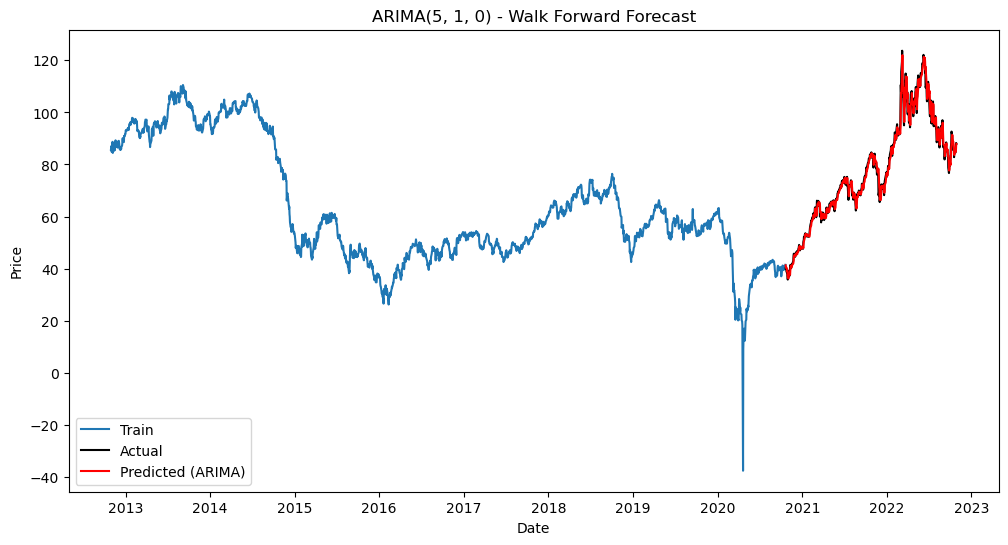

In [84]:
# Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(test.index, preds, label="Predicted (ARIMA)", color="red")
plt.title(f"ARIMA{order} - Walk Forward Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()